# From Raw Movie Plots to a Domain Knowledge Graph

**Case-study notebook** for the NLP mini-project: *From Raw Text to Domain Knowledge Graph*.

The goal is to build a mini KG pipeline from a movie-plot corpus:

1. load and document a corpus sample;
2. extract triples with two different strategies;
3. normalize entities and relations;
4. construct graph artifacts;
5. compare extraction coverage;
6. prepare a manual precision audit;
7. summarize graph statistics, frequent relations, and common error categories after manual labeling.

## Extraction strategies

### Strategy A — real rule-based baseline
This method uses **hand-written lexical patterns only**. It is intentionally simple, transparent, and high-precision/low-recall.

### Strategy B — off-the-shelf NLP extraction
This method uses `textacy.extract.subject_verb_object_triples()`, an off-the-shelf SVO triple extractor built on spaCy parses. The notebook only normalizes and filters the triples after extraction; it does not manually code dependency rules for relation extraction.

## 0. Environment setup

In [4]:
# %pip install -q pandas numpy spacy textacy networkx matplotlib tqdm
# !python -m spacy download en_core_web_sm

In [5]:
from pathlib import Path
import re
import unicodedata

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import spacy
from tqdm.auto import tqdm


from textacy.extract import subject_verb_object_triples


pd.set_option("display.max_colwidth", None)


RANDOM_SEED = 0
BASE_DIR = Path(".")
OUTPUT_DIR = BASE_DIR / "results"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 1. Load and sample the corpus

The corpus is the public Wiki Movie Plots dataset. The project uses a controlled sample rather than the full dataset so that parsing and manual audit remain feasible

In [6]:
DATA_URL = "https://huggingface.co/datasets/vishnupriyavr/wiki-movie-plots-with-summaries/resolve/main/wiki_movie_plots_deduped_with_summaries.csv"
SAMPLE_SIZE = 400
MIN_PLOT_CHARS = 300
MAX_PLOT_CHARS = 2500

raw_df = pd.read_csv(DATA_URL)
print(f"Raw rows: {len(raw_df):,}")
print(raw_df.columns.tolist())

# Use English-heavy origins to reduce multilingual/noisy effects in a small class project.
df = raw_df.copy()
df = df[df["Plot"].notna()].copy()

# Filter plots by length to remove very short/noisy summaries
# and extremely long ones that slow down processing
df = df[df["Plot"].str.len().between(MIN_PLOT_CHARS, MAX_PLOT_CHARS)].copy()
df = df[df["Origin/Ethnicity"].fillna("").str.contains("American|British", case=False, regex=True)].copy()
df = df[["Title", "Release Year", "Genre", "Origin/Ethnicity", "Plot"]].drop_duplicates("Plot")


# Sample a subset for reproducibility and faster experimentation
# Same sample is used for both methods to ensure fair comparison
df = df.sample(min(SAMPLE_SIZE, len(df)), random_state=RANDOM_SEED).reset_index(drop=True)
df["plot_chars"] = df["Plot"].str.len()

print(f"Filtered and sampled rows: {len(df):,}")
df.head(2)

Raw rows: 34,886
['Release Year', 'Title', 'Origin/Ethnicity', 'Director', 'Cast', 'Genre', 'Wiki Page', 'Plot', 'PlotSummary']
Filtered and sampled rows: 400


,Title,Release Year,Genre,Origin/Ethnicity,Plot,plot_chars
0,My Outlaw Brother,1951,western,American,"Denny O'Moore, an Irish lad from New York, has not seen big brother Patrick for eight years. Patrick is said to now own a silver mine in Mexico and sends welcome money to his family in America.\r\nIn the town of Border City, Texas, a bandit known as ""El Tigre"" blows up and robs a bank. El Tigre is a dangerous killer with a large gang wanted on both sides of the border. The Mexican Secret Service who have attempted to infiltrate El Tigre's gang have had all of their operatives killed or disappeared. Their representative approaches the Texas Rangers with a plan. El Tigre's right-hand man is an American, Patrick O'Moore. The Mexicans assume that if a Ranger approaches O'Moore and gets him back to America he would be willing to betray El Tigre for money and amnesty. Ranger Joe Warder is assigned to go to Mexico and bring O'Moore across the border.\r\nOn the trail, bandits attack Denny but he is saved by Joe. Discovering Denny's brother is the man he is after, Joe teams up with Denny and ride together to San Clemente, Mexico where Patrick resides. Denny discovers a woman there, Carmelita Alvarado, is loved by Patrick but wants nothing to do with him.\r\nDenny is seized by El Tigre's men, but keeping out of Denny's view, Patrick saves him. Patrick tells the men he has no brother, but orders his men not to harm Danny and return him to the United States unharmed. Patrick later finds Danny and tells him he owes his life to El Tigre, who once saved it.\r\nAfter being held captive, Denny, Joe and Carmelita flee. A friend who helps them escape is killed by El Tigre, who comes at Denny with a machete. Joe shoots him. El Tigre is revealed to be Patrick in disguise.\r\nThe Americans ride off for home, and Carmelita decides to go along with Denny.",1751
1,The Yellow Balloon,1953,drama,British,"In London's East End, 12-year-old Frankie Palmer (Andrew Ray) loses the sixpence his father has given him to buy a large yellow balloon from a street seller that the boy has set his heart on. He sees that a friend of his, young Ronnie Williams (Stephen Fenemore) has already bought one and Frankie snatches it off him and runs off with it, with Ronnie in hot pursuit. Ronnie chases Frankie into a large, bombed-out house and they are running about in the ruins when Ronnie slips and falls thirty feet to his death. Frankie scrambles down to help, but realises that there is nothing he can do. Hiding in the shadows and seeing it all, Len Turner (William Sylvester), a criminal on the run and using the ruins as a hideout from the police, convinces Frankie that the police will arrest the boy and charge him with the murder of his friend for pushing him to his death and that they must both make their getaway. Although Frankie and Len agree it was an accident, Len is adamant that the police will not see it that way and Frankie goes off with him. Len blackmails Frankie into stealing money from his parents (Kenneth More and Kathleen Ryan) to help fund Len's escape and then uses the boy as a decoy in a pub robbery that goes horribly wrong when Len murders the pub owner. Realising that Frankie is the only witness to his crime, Len knows he must kill the boy, too. This develops into a terrifying hide-and-seek chase through a bomb-damaged, abandoned and highly-perilous London Underground station, with Len hot on the heels of Frankie, who is desperately trying to escape with his life.",1590


In [7]:
summary_table = pd.DataFrame({
    "metric": ["sample_size", "mean_plot_chars", "median_plot_chars", "min_plot_chars", "max_plot_chars", "unique_genres"],
    "value": [
        len(df),
        round(df["plot_chars"].mean(), 1),
        round(df["plot_chars"].median(), 1),
        int(df["plot_chars"].min()),
        int(df["plot_chars"].max()),
        int(df["Genre"].nunique()),
    ],
})
summary_table

,metric,value
0,sample_size,400.0
1,mean_plot_chars,1181.9
2,median_plot_chars,1031.0
3,min_plot_chars,303.0
4,max_plot_chars,2493.0
5,unique_genres,66.0


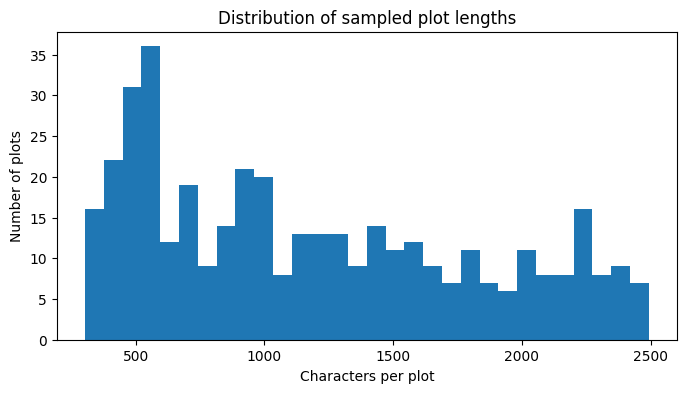

Genre
drama             102
comedy             76
western            21
crime              20
unknown            18
musical            12
crime drama        12
horror             10
thriller           10
romance             8
mystery             7
musical comedy      6
Name: count, dtype: int64

In [8]:
ax = df["plot_chars"].plot(kind="hist", bins=30, figsize=(8, 4), title="Distribution of sampled plot lengths")
ax.set_xlabel("Characters per plot")
ax.set_ylabel("Number of plots")
plt.show()

df["Genre"].fillna("Unknown").value_counts().head(12)

## 2. Parse the corpus once with spaCy

The rule-based extractor below does not rely on this parse. The parse is needed for the off-the-shelf `textacy` SVO extractor and for optional sentence segmentation.

In [9]:
nlp = spacy.load("en_core_web_sm")


nlp.max_length = 1_000_000

docs = list(tqdm(nlp.pipe(df["Plot"].tolist(), batch_size=16), total=len(df), desc="Parsing plots"))
df["doc"] = docs
df["sentence_count"] = [sum(1 for _ in doc.sents) for doc in docs]
df[["Title", "sentence_count", "plot_chars"]].head()

Parsing plots:   0%|          | 0/400 [00:00<?, ?it/s]

,Title,sentence_count,plot_chars
0,My Outlaw Brother,20,1751
1,The Yellow Balloon,9,1590
2,Three Young Texans,13,1118
3,The Great Diamond Robbery,11,1178
4,Beware of Bachelors,6,669


## 3. Shared normalization and validation

Both methods produce raw triples. After extraction, triples are normalized in the same way so that the comparison is fairer. The normalization is deliberately conservative: it standardizes whitespace, quotes, case variants, and relation lemmas, but it does not pretend to solve full entity linking or coreference.

In [10]:
BAD_ENTITY_STARTS = {
    "the", "a", "an", "this", "that", "these", "those", "his", "her", "their", "its",
    "he", "she", "they", "it", "him", "them", "someone", "something", "one", "two",
    "later", "meanwhile", "eventually", "however", "there", "when", "while", "after", "before"
}

RELATION_SYNONYMS = {
    "weds": "marries",
    "wed": "marries",
    "marries": "marries",
    "marry": "marries",
    "kills": "kills",
    "kill": "kills",
    "murders": "kills",
    "murder": "kills",
    "shoots": "shoots",
    "shoot": "shoots",
    "kidnaps": "kidnaps",
    "kidnap": "kidnaps",
    "abducts": "kidnaps",
    "abduct": "kidnaps",
    "meets": "meets",
    "meet": "meets",
    "helps": "helps",
    "help": "helps",
    "rescues": "rescues",
    "rescue": "rescues",
    "saves": "saves",
    "save": "saves",
    "betrays": "betrays",
    "betray": "betrays",
    "joins": "joins",
    "join": "joins",
    "finds": "finds",
    "find": "finds",
    "discovers": "discovers",
    "discover": "discovers",
    "loves": "loves",
    "love": "loves",
    "hates": "hates",
    "hate": "hates",
    "travels to": "travels_to",
    "goes to": "travels_to",
    "returns to": "returns_to",
    "works for": "works_for",
    "is hired by": "hired_by",
    "is arrested by": "arrested_by",
}

def normalize_text(text: str) -> str:
    text = unicodedata.normalize("NFKC", str(text))
    text = text.replace("’", "'").replace("‘", "'").replace('“', '"').replace('”', '"')
    text = re.sub(r"\s+", " ", text).strip(" \t\n\r.,;:!?()[]{}\"'")
    return text


def normalize_entity(text: str) -> str:
    text = normalize_text(text)
    text = re.sub(r"^(Mr|Mrs|Ms|Dr|Professor|Prof|Sir|Lady)\.\s+", "", text)
    text = re.sub(r"\b('s|s')$", "", text)
    return text


def normalize_relation(text: str) -> str:
    text = normalize_text(text).lower()
    text = re.sub(r"\s+", " ", text)
    return RELATION_SYNONYMS.get(text, text.replace(" ", "_"))


def is_valid_entity(ent: str) -> bool:
    ent = normalize_entity(ent)
    if len(ent) < 2 or len(ent) > 80:
        return False
    if ent.lower().split()[0] in BAD_ENTITY_STARTS:
        return False
    if not re.search(r"[A-Za-z]", ent):
        return False
    if ent.count(" ") > 7:
        return False
    return True


def finalize_triples(rows, strategy_name: str) -> pd.DataFrame:
    cols = ["strategy", "title", "sentence", "head", "relation", "tail"]
    if not rows:
        return pd.DataFrame(columns=cols + ["head_norm", "relation_norm", "tail_norm", "support_count", "example_title", "example_sentence"])
    triples = pd.DataFrame(rows)
    triples["strategy"] = strategy_name
    triples["head_norm"] = triples["head"].map(normalize_entity)
    triples["relation_norm"] = triples["relation"].map(normalize_relation)
    triples["tail_norm"] = triples["tail"].map(normalize_entity)
    triples = triples[
        triples["head_norm"].map(is_valid_entity)
        & triples["tail_norm"].map(is_valid_entity)
        & (triples["head_norm"].str.lower() != triples["tail_norm"].str.lower())
    ].copy()

    grouped = (
        triples.groupby(["strategy", "head_norm", "relation_norm", "tail_norm"], as_index=False)
        .agg(
            support_count=("sentence", "count"),
            example_title=("title", "first"),
            example_sentence=("sentence", "first"),
        )
        .sort_values(["support_count", "head_norm"], ascending=[False, True])
        .reset_index(drop=True)
    )
    return grouped

## 4. Strategy A: rule-based extraction

This baseline uses a small set of transparent lexical patterns. Examples:

- `X kills Y`
- `X marries Y`
- `X travels to Y`
- `X works for Y`

The extraction logic is fully specified by regular expressions and does not use an NLP parser

In [11]:
# Conservative entity-like phrase pattern. This is intentionally not NER.
ENTITY = r"(?:[A-Z][A-Za-z'\-]+|[A-Z]{2,})(?:\s+(?:[A-Z][A-Za-z'\-]+|[A-Z]{2,})){0,4}"

RULE_SPECS = [
    ("kills",       rf"(?P<head>{ENTITY})\s+(?:eventually\s+|later\s+)?(?:kills|murders)\s+(?P<tail>{ENTITY})"),
    ("shoots",      rf"(?P<head>{ENTITY})\s+(?:shoots)\s+(?P<tail>{ENTITY})"),
    ("kidnaps",     rf"(?P<head>{ENTITY})\s+(?:kidnaps|abducts)\s+(?P<tail>{ENTITY})"),
    ("marries",     rf"(?P<head>{ENTITY})\s+(?:marries|weds)\s+(?P<tail>{ENTITY})"),
    ("meets",       rf"(?P<head>{ENTITY})\s+(?:meets|encounters)\s+(?P<tail>{ENTITY})"),
    ("helps",       rf"(?P<head>{ENTITY})\s+(?:helps|assists)\s+(?P<tail>{ENTITY})"),
    ("rescues",     rf"(?P<head>{ENTITY})\s+(?:rescues|saves)\s+(?P<tail>{ENTITY})"),
    ("betrays",     rf"(?P<head>{ENTITY})\s+(?:betrays|double-crosses)\s+(?P<tail>{ENTITY})"),
    ("joins",       rf"(?P<head>{ENTITY})\s+(?:joins)\s+(?P<tail>{ENTITY})"),
    ("loves",       rf"(?P<head>{ENTITY})\s+(?:loves|falls in love with)\s+(?P<tail>{ENTITY})"),
    ("hates",       rf"(?P<head>{ENTITY})\s+(?:hates)\s+(?P<tail>{ENTITY})"),
    ("finds",       rf"(?P<head>{ENTITY})\s+(?:finds|discovers)\s+(?P<tail>{ENTITY})"),
    ("travels to",  rf"(?P<head>{ENTITY})\s+(?:travels|goes|returns)\s+to\s+(?P<tail>{ENTITY})"),
    ("works for",   rf"(?P<head>{ENTITY})\s+works\s+for\s+(?P<tail>{ENTITY})"),
    ("is hired by", rf"(?P<head>{ENTITY})\s+is\s+hired\s+by\s+(?P<tail>{ENTITY})"),
    ("is arrested by", rf"(?P<head>{ENTITY})\s+is\s+arrested\s+by\s+(?P<tail>{ENTITY})"),
]

RULE_PATTERNS = [(rel, re.compile(pattern)) for rel, pattern in RULE_SPECS]
SENTENCE_SPLIT_RE = re.compile(r"(?<=[.!?])\s+")


def extract_rule_based_triples(text: str, title: str):
    rows = []
    for sentence in SENTENCE_SPLIT_RE.split(str(text)):
        sentence = normalize_text(sentence)
        if not sentence:
            continue
        for relation, pattern in RULE_PATTERNS:
            for m in pattern.finditer(sentence):
                head = normalize_entity(m.group("head"))
                tail = normalize_entity(m.group("tail"))
                if is_valid_entity(head) and is_valid_entity(tail):
                    rows.append({
                        "title": title,
                        "sentence": sentence,
                        "head": head,
                        "relation": relation,
                        "tail": tail,
                    })
    return rows

In [12]:
rule_rows = []
for row in df.itertuples(index=False):
    rule_rows.extend(extract_rule_based_triples(row.Plot, row.Title))

rule_triples = finalize_triples(rule_rows, strategy_name="rule_based_regex")
print(f"Raw rule-based extractions: {len(rule_rows):,}")
print(f"Unique normalized rule-based triples: {len(rule_triples):,}")
rule_triples.head(15)

Raw rule-based extractions: 35
Unique normalized rule-based triples: 35


,strategy,head_norm,relation_norm,tail_norm,support_count,example_title,example_sentence
0,rule_based_regex,Andy,loves,Jeff,1,Kiss the Sky,"After a period together, Jeff misses his family and the relationship of the group deteriorates when Andy falls in love with Jeff"
1,rule_based_regex,Ann,shoots,Duke,1,Private Property,"Roger returns home, fights Duke, and Ann shoots Duke"
2,rule_based_regex,Bugs,shoots,Sam,1,Bugs Bunny Rides Again,"Bugs and Sam draws out increasingly bigger guns; Bugs shoots Sam's nose with a pea shooter, and, after performing a soft shoe routine, tricks him into falling into a mine shaft.[4] When Sam returns to the surface, Bugs dares him to cross lines drawn with his foot Sam does so until he falls off the cliff"
3,rule_based_regex,Craig,marries,Ellen,1,Marine Raiders,"Preparing for an invasion of an unnamed South Pacific island whilst back in Australia, Craig marries Ellen"
4,rule_based_regex,Denny,helps,Andy,1,The Upside of Anger,"Keen to help where he can, Denny helps Andy, one of Terry's daughters, to become a production assistant at the radio station where he works"
5,rule_based_regex,Denton,shoots,Montefiori,1,The Light at the Edge of the World,"On the next day, Kongre has Montefiori flayed alive on his ship, trying to draw Denton out of hiding, but Denton shoots Montefiori from afar"
6,rule_based_regex,Ellen,marries,Edwin,1,Wonder Man,"In the end, Ellen marries Edwin, whilst Midge consoles herself (apparently without regret) by marrying the owner of the club where Buster was appearing"
7,rule_based_regex,Felice,loves,Stephen,1,Adventure in Diamonds,"While they wait to be contacted by the gang, Felice and Stephen spend some quality time together, and Felice falls in love with Stephen for real"
8,rule_based_regex,Freddie Fletcher,rescues,Elizabeth,1,Dry Martini,Quimby's young pal Freddie Fletcher saves Elizabeth from the clutches of de Launay in the nick of time
9,rule_based_regex,Grendel,kills,Hrothgar,1,Beowulf,"Grendel kills Hrothgar, after the truth of his heritage is revealed"


## 5. Strategy B: off-the-shelf Subject, Verb, Object extraction with textacy

The relation-extraction step is delegated to `textacy.extract.subject_verb_object_triples()`. The code:

1. calls the off-the-shelf extractor;
2. converts returned token spans into strings;
3. performs the same normalization and validation used for the rule-based method.

In [13]:
def span_to_text(span_tokens) -> str:
    # textacy returns token sequences for subject, verb, and object.
    return normalize_text(" ".join(tok.text for tok in span_tokens))


# Normalize triples to reduce duplicates:
# - lowercase
# - strip whitespace
# - unify formatting

def clean_svo_relation(verb_text: str) -> str:
    # Keep the relation as extracted, but reduce auxiliaries/noise for graph labels.
    verb_text = normalize_text(verb_text).lower()
    verb_text = re.sub(r"\b(is|are|was|were|be|been|being|has|have|had|does|do|did)\b", "", verb_text)
    verb_text = re.sub(r"\s+", " ", verb_text).strip()
    return verb_text if verb_text else "related_to"


def extract_textacy_svo_triples(doc, title: str):
    rows = []
    for sent in doc.sents:
        sent_text = normalize_text(sent.text)
        for triple in subject_verb_object_triples(sent):
            head = normalize_entity(span_to_text(triple.subject))
            relation = clean_svo_relation(span_to_text(triple.verb))
            tail = normalize_entity(span_to_text(triple.object))
            if is_valid_entity(head) and is_valid_entity(tail):
                rows.append({
                    "title": title,
                    "sentence": sent_text,
                    "head": head,
                    "relation": relation,
                    "tail": tail,
                })
    return rows

In [14]:
textacy_rows = []
for row in tqdm(df.itertuples(index=False), total=len(df), desc="Extracting textacy SVO triples"):
    textacy_rows.extend(extract_textacy_svo_triples(row.doc, row.Title))

textacy_triples = finalize_triples(textacy_rows, strategy_name="off_the_shelf_textacy_svo")
print(f"Raw textacy SVO extractions: {len(textacy_rows):,}")
print(f"Unique normalized textacy SVO triples: {len(textacy_triples):,}")
textacy_triples.head(15)

Extracting textacy SVO triples:   0%|          | 0/400 [00:00<?, ?it/s]

Raw textacy SVO extractions: 2,449
Unique normalized textacy SVO triples: 2,439


,strategy,head_norm,relation_norm,tail_norm,support_count,example_title,example_sentence
0,off_the_shelf_textacy_svo,Bill,tells,Cora,2,Lucky Night,"Someone leaves a coin on the table, Bill tells Cora to steal it, which she does"
1,off_the_shelf_textacy_svo,Sydney,sees,girl,2,The Eye,Sydney sees the little girl from her vision in the car next to her
2,off_the_shelf_textacy_svo,action,takes,place,2,Tread Softly Stranger,The action takes place in the Yorkshire steel town of Rawborough – Rotherham was used for the extensive location filming – to which native son Johnny Mansell (George Baker) has fled after racking up large gambling debts in London
3,off_the_shelf_textacy_svo,bosses,ask,Eric,2,Thanks a Million,"Impressed by his poise, the party's bosses ask Eric to take over as candidate"
4,off_the_shelf_textacy_svo,couple,raised,children,2,"Red Robin, TheThe Red Robin","As Dr. Shellner lies on his death bed on a frigid, icy day on the fringes of New York City in suburban New Jersey, the family convenes at the house where the couple raised the children for a final, bittersweet farewell to a sensational and inspiring public figure"
5,off_the_shelf_textacy_svo,film,follows,couple,2,Inadmissible Evidence,"The film follows a couple of days in the life of Bill Maitland, a 39-year-old Englishman who is head of small law firm in London and is tortured by his inadequacies as a lawyer, as an employer, as a husband, as a father, as a friend (he has none) and as a lover (for though women succumb quickly to him, he cannot maintain a relationship"
6,off_the_shelf_textacy_svo,film,takes,place,2,I Will Repay,"The film takes place in Paris, 1793: during the Reign of Terror"
7,off_the_shelf_textacy_svo,- teen,adopted,daughter Annie,1,Lovely & Amazing,"The story focuses on Jane Marks, her adult daughters Michelle and Elizabeth, and her pre-teen adopted African American daughter Annie, each of whom allows her personal insecurities to affect her life"
8,off_the_shelf_textacy_svo,Abbey,appears,Floyd,1,Fearless Fagan,Abbey then appears and leads Floyd to the outdoor pool where they find Fagan jumping from the diving board and swimming to safety
9,off_the_shelf_textacy_svo,Abbey,leads,Floyd,1,Fearless Fagan,Abbey then appears and leads Floyd to the outdoor pool where they find Fagan jumping from the diving board and swimming to safety


## 6. Coverage comparison before manual audit

These are not quality scores. They measure coverage and graph size only

In [15]:
# Compute coverage metrics:
# - number of triples
# - number of entities
# - number of relation types
# These reflect recall / coverage of each method

def coverage_stats(triples: pd.DataFrame, raw_count: int, strategy: str) -> dict:
    if triples.empty:
        return {
            "strategy": strategy,
            "raw_extractions": raw_count,
            "unique_triples": 0,
            "unique_entities": 0,
            "relation_types": 0,
            "mean_support": 0,
            "median_support": 0,
        }
    entities = set(triples["head_norm"]).union(set(triples["tail_norm"]))
    return {
        "strategy": strategy,
        "raw_extractions": raw_count,
        "unique_triples": len(triples),
        "unique_entities": len(entities),
        "relation_types": triples["relation_norm"].nunique(),
        "mean_support": round(triples["support_count"].mean(), 2),
        "median_support": round(triples["support_count"].median(), 2),
    }

comparison = pd.DataFrame([
    coverage_stats(rule_triples, len(rule_rows), "rule_based_regex"),
    coverage_stats(textacy_triples, len(textacy_rows), "off_the_shelf_textacy_svo"),
])
comparison

,strategy,raw_extractions,unique_triples,unique_entities,relation_types,mean_support,median_support
0,rule_based_regex,35,35,64,9,1.0,1.0
1,off_the_shelf_textacy_svo,2449,2439,2589,1091,1.0,1.0


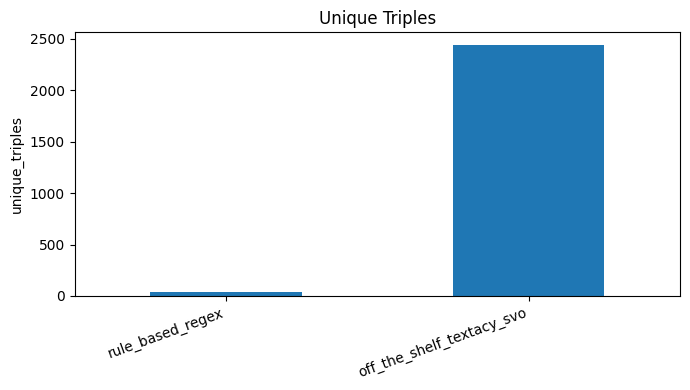

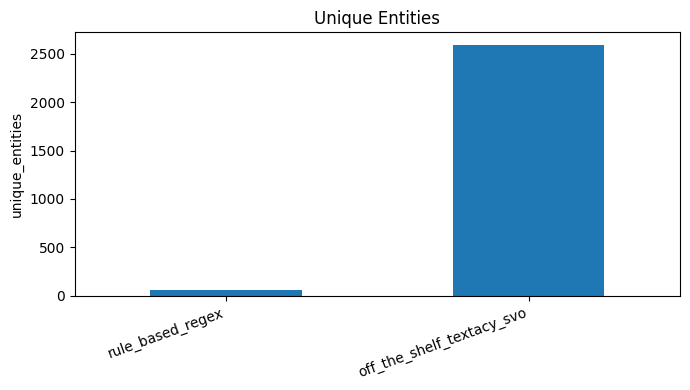

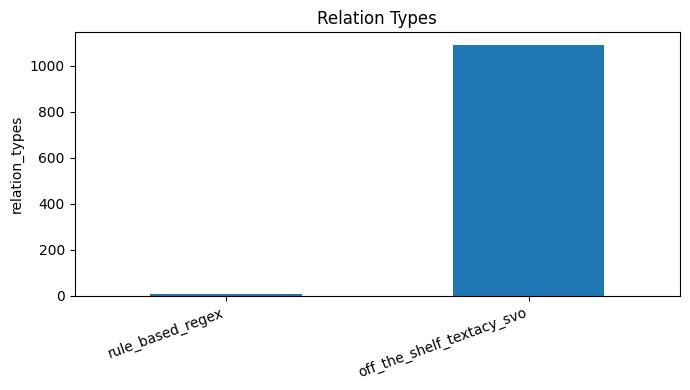

In [16]:
for metric in ["unique_triples", "unique_entities", "relation_types"]:
    ax = comparison.plot(kind="bar", x="strategy", y=metric, legend=False, figsize=(7, 4), title=metric.replace("_", " ").title())
    ax.set_xlabel("")
    ax.set_ylabel(metric)
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()

## 7. Inspect extracted relations and examples

This section makes the extraction behavior interpretable before manual audit.

In [17]:
def top_relations(triples: pd.DataFrame, k=15):
    if triples.empty:
        return pd.DataFrame(columns=["relation_norm", "triple_count", "support_count"])
    return (
        triples.groupby("relation_norm", as_index=False)
        .agg(triple_count=("relation_norm", "size"), support_count=("support_count", "sum"))
        .sort_values(["triple_count", "support_count"], ascending=False)
        .head(k)
    )

print("Rule-based top relations")
display(top_relations(rule_triples))
print("Off-the-shelf textacy top relations")
display(top_relations(textacy_triples))

Rule-based top relations


,relation_norm,triple_count,support_count
8,travels_to,9,9
3,loves,8,8
5,meets,6,6
7,shoots,3,3
0,finds,2,2
1,helps,2,2
2,kills,2,2
4,marries,2,2
6,rescues,1,1


Off-the-shelf textacy top relations


,relation_norm,triple_count,support_count
758,related_to,89,89
917,takes,43,45
81,begins,31,31
997,tries,31,31
364,finds,30,30
395,gives,25,25
927,tells,23,24
389,gets,21,21
501,killed,21,21
503,kills,20,20


In [18]:
def show_examples(triples: pd.DataFrame, k=10):
    if triples.empty:
        return pd.DataFrame()
    cols = ["head_norm", "relation_norm", "tail_norm", "support_count", "example_title", "example_sentence"]
    return triples[cols].sample(min(k, len(triples)), random_state=RANDOM_SEED)

print("Random rule-based examples")
display(show_examples(rule_triples, k=5))
print("Random off-the-shelf examples")
display(show_examples(textacy_triples, k=5))

Random rule-based examples


,head_norm,relation_norm,tail_norm,support_count,example_title,example_sentence
29,Roy,meets,Betty Weston,1,The Yellow Rose of Texas,"Portraying a performer on a showboat as an undercover guise, Roy meets Betty Weston (Dale Evans), the daughter of the alleged robber Sam Weston (Harry Shannon), who has recently escaped from prison"
20,Leif,kills,Egil,1,The Viking,"Leif kills Egil, but is enraged when Helga reveals that she loves Alwin"
16,Junior,loves,Milo,1,Surf Party,"While the girls are learning to surf, Terry falls in love with Len (Bobby Vinton), the operator of a local surf shop; Junior falls in love with Milo (Ken Miller), a new surfer; and Sylvia falls in love with Skeet (Jerry Summers"
28,Ralph,travels_to,New York,1,New Morals for Old,"Eventually, Phyl marries her paramour and Ralph returns to New York, having failed as an artist"
22,O'Hara,finds,Weber,1,Secret Venture,"O'Hara finds Weber (Frederick Valk) in Paris, and learns that he now has the briefcase in his possession but is unable to decipher the contents which appear to be written in a complex code"


Random off-the-shelf examples


,head_norm,relation_norm,tail_norm,support_count,example_title,example_sentence
1779,information,enables,Dorval accomplice,1,Men of Chance,"Marthe's inside information enables Dorval and an accomplice, bookie Joe Farley, to bribe Johnny's jockeys to deliberately lose races or to help them influence the odds"
2126,use,to_recruit,Irregulars,1,The Battle of Rogue River,"On arrival at the Fort, Major Wallach has allowed the use of his barracks to recruit more Irregulars for Stacey Wyatt (Richard Denning) who accompany the regulars on their military expeditions"
949,Miss Daisy,attends,dinner,1,Driving Miss Daisy,"But American society is undergoing radical changes, and Miss Daisy attends a dinner at which Dr. Martin Luther King gives a speech"
1467,both,wear,hat,1,The Boat,Buster is married with two children (both of whom wear the porkpie hat made famous by Keaton
135,Boolie,drives,Hoke,1,Driving Miss Daisy,"Boolie, now 65, drives Hoke to the retirement home to visit Miss Daisy, now 97.[4"


## 8. Build graph artifacts

The graph is a directed multigraph: entity nodes are connected by labeled relation edges

In [19]:
def triples_to_graph(triples: pd.DataFrame) -> nx.MultiDiGraph:
    G = nx.MultiDiGraph()
    for row in triples.itertuples(index=False):
        G.add_node(row.head_norm, label=row.head_norm)
        G.add_node(row.tail_norm, label=row.tail_norm)
        G.add_edge(
            row.head_norm,
            row.tail_norm,
            relation=row.relation_norm,
            support_count=int(row.support_count),
            example_title=str(row.example_title),
            example_sentence=str(row.example_sentence),
        )
    return G

In [20]:
rule_graph = triples_to_graph(rule_triples)
textacy_graph = triples_to_graph(textacy_triples)

def graph_stats(G: nx.MultiDiGraph, strategy: str) -> dict:
    if G.number_of_nodes() == 0:
        return {"strategy": strategy, "nodes": 0, "edges": 0, "weak_components": 0, "largest_component_nodes": 0, "density": 0}
    weak_components = list(nx.weakly_connected_components(G))
    return {
        "strategy": strategy,
        "nodes": G.number_of_nodes(),
        "edges": G.number_of_edges(),
        "weak_components": len(weak_components),
        "largest_component_nodes": max(len(c) for c in weak_components),
        "density": round(nx.density(nx.DiGraph(G)), 6),
    }

graph_summary = pd.DataFrame([
    graph_stats(rule_graph, "rule_based_regex"),
    graph_stats(textacy_graph, "off_the_shelf_textacy_svo"),
])
graph_summary

,strategy,nodes,edges,weak_components,largest_component_nodes,density
0,rule_based_regex,64,35,29,4,0.008681
1,off_the_shelf_textacy_svo,2589,2439,482,1414,0.000338


In [28]:
def top_degree_nodes(G: nx.MultiDiGraph, k=15):
    if G.number_of_nodes() == 0:
        return pd.DataFrame(columns=["entity", "degree", "in_degree", "out_degree"])
    rows = []
    for node in G.nodes():
        rows.append({
            "entity": node,
            "degree": G.degree(node),
            "in_degree": G.in_degree(node),
            "out_degree": G.out_degree(node),
        })
    return pd.DataFrame(rows).sort_values("degree", ascending=False).head(k)

In [29]:
print("Top rule-based graph nodes")
display(top_degree_nodes(rule_graph))
print("Top off-the-shelf graph nodes")
display(top_degree_nodes(textacy_graph))

Top rule-based graph nodes


,entity,degree,in_degree,out_degree
41,O'Hara,3,0,3
0,Andy,2,1,1
25,Mexico,2,2,0
5,Sam,2,2,0
7,Ellen,2,1,1
46,Jezebel,1,1,0
45,Once Jehu,1,0,1
44,Scotland Yard,1,1,0
43,London,1,1,0
42,Weber,1,1,0


Top off-the-shelf graph nodes


,entity,degree,in_degree,out_degree
2431,who,238,0,238
573,which,37,8,29
10,film,24,0,24
930,police,24,9,15
788,Tom,23,2,21
809,Jim,22,2,20
1194,father,22,5,17
240,himself,20,14,6
68,job,19,19,0
786,Jerry,19,8,11


In [30]:
def plot_kg(G, title="Knowledge Graph", max_nodes=20):
    
    degree_nodes = [node for node, _ in sorted(G.degree, key=lambda x: x[1], reverse=True)[:max_nodes]]
    G = G.subgraph(degree_nodes)

    plt.figure(figsize=(12, 8))

    # Layout
    pos = nx.spring_layout(G, seed=42)

    # Draw nodes
    nx.draw_networkx_nodes(
        G, pos,
        node_size=700,
        node_color="lightblue",
        alpha=0.9
    )

    # Draw node labels
    nx.draw_networkx_labels(
        G, pos,
        font_size=9,
        font_weight="bold"
    )

    # Draw edges
    nx.draw_networkx_edges(
        G, pos,
        edge_color="gray",
        arrows=True,
        arrowsize=20,      
        width=1.5,
        alpha=0.9,         # transparency
        connectionstyle="arc3,rad=0.1"  # slight curve for readability
    )

    # edge labels (relations)
    edge_labels = {
        (u, v): d.get("relation", "")
        for u, v, d in G.edges(data=True)
    }

    nx.draw_networkx_edge_labels(
		G,
		pos,
		edge_labels=edge_labels,
		font_size=8,
		font_weight="bold",
		label_pos=0.5,
		rotate=False,
		bbox=dict(
			boxstyle="round,pad=0.18",
			facecolor="white",
			edgecolor="black",
			linewidth=0.3,
			alpha=0.9,        # less transparent
		),
	)

    plt.title(title)
    plt.axis("off")
    plt.show()

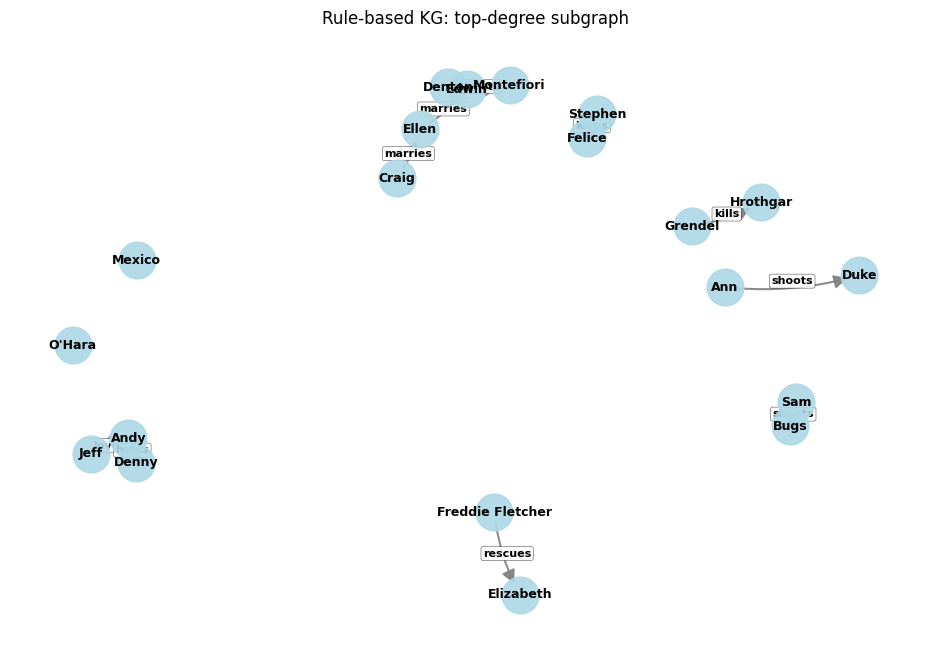

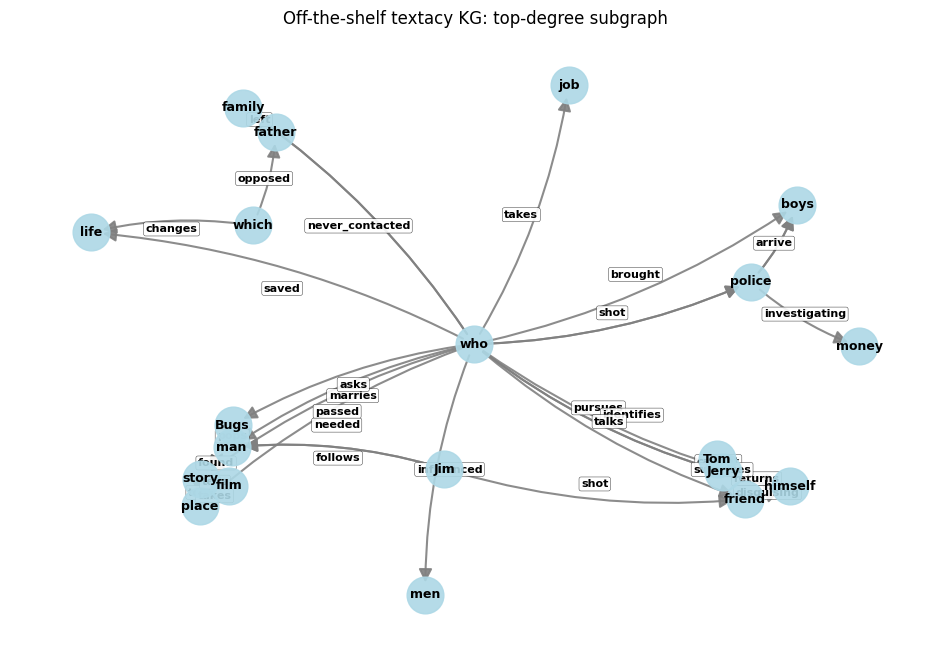

In [31]:
plot_kg(rule_graph, "Rule-based KG: top-degree subgraph")
plot_kg(textacy_graph, "Off-the-shelf textacy KG: top-degree subgraph")

## 9. Save artifacts

In [32]:
rule_triples.to_csv(OUTPUT_DIR / "triples_rule_based_regex.csv", index=False)
textacy_triples.to_csv(OUTPUT_DIR / "triples_off_the_shelf_textacy_svo.csv", index=False)
comparison.to_csv(OUTPUT_DIR / "coverage_comparison.csv", index=False)
graph_summary.to_csv(OUTPUT_DIR / "graph_summary.csv", index=False)

nx.write_graphml(rule_graph, OUTPUT_DIR / "kg_rule_based_regex.graphml")
nx.write_graphml(textacy_graph, OUTPUT_DIR / "kg_off_the_shelf_textacy_svo.graphml")

print("Saved artifacts:")
for path in sorted(OUTPUT_DIR.iterdir()):
    print(" -", path)

Saved artifacts:
 - results/coverage_comparison.csv
 - results/graph_summary.csv
 - results/kg_off_the_shelf_textacy_svo.graphml
 - results/kg_rule_based_regex.graphml
 - results/manual_audit_done.csv
 - results/manual_audit_template.csv
 - results/off-shelf-graph.png
 - results/rule-graph.png
 - results/triples_off_the_shelf_textacy_svo.csv
 - results/triples_rule_based_regex.csv


## 10. Manual precision audit

In [33]:
def build_audit_sample(triples: pd.DataFrame, strategy: str, n=40) -> pd.DataFrame:
    cols = [
        "strategy", "head_norm", "relation_norm", "tail_norm", "support_count",
        "example_title", "example_sentence", "is_correct", "notes"
    ]
    if triples.empty:
        return pd.DataFrame(columns=cols)
    sample = triples.sample(min(n, len(triples)), random_state=RANDOM_SEED).copy()
    sample["strategy"] = strategy
    sample["is_correct"] = np.nan
    sample["notes"] = ""
    return sample[cols]

audit_df = pd.concat([
    build_audit_sample(rule_triples, "rule_based_regex", n=10),
    build_audit_sample(textacy_triples, "off_the_shelf_textacy_svo", n=10),
], ignore_index=True)

audit_path = OUTPUT_DIR / "manual_audit_template.csv"
audit_df.to_csv(audit_path, index=False)
print(f"Audit template saved to: {audit_path}")
audit_df.head(4)

Audit template saved to: results/manual_audit_template.csv


,strategy,head_norm,relation_norm,tail_norm,support_count,example_title,example_sentence,is_correct,notes
0,rule_based_regex,Roy,meets,Betty Weston,1,The Yellow Rose of Texas,"Portraying a performer on a showboat as an undercover guise, Roy meets Betty Weston (Dale Evans), the daughter of the alleged robber Sam Weston (Harry Shannon), who has recently escaped from prison",NaN,
1,rule_based_regex,Leif,kills,Egil,1,The Viking,"Leif kills Egil, but is enraged when Helga reveals that she loves Alwin",NaN,
2,rule_based_regex,Junior,loves,Milo,1,Surf Party,"While the girls are learning to surf, Terry falls in love with Len (Bobby Vinton), the operator of a local surf shop; Junior falls in love with Milo (Ken Miller), a new surfer; and Sylvia falls in love with Skeet (Jerry Summers",NaN,
3,rule_based_regex,Ralph,travels_to,New York,1,New Morals for Old,"Eventually, Phyl marries her paramour and Ralph returns to New York, having failed as an artist",NaN,


,strategy,audited_triples,correct_triples,precision,precision_pct
0,off_the_shelf_textacy_svo,10,6,0.6,60.0
1,rule_based_regex,10,9,0.9,90.0


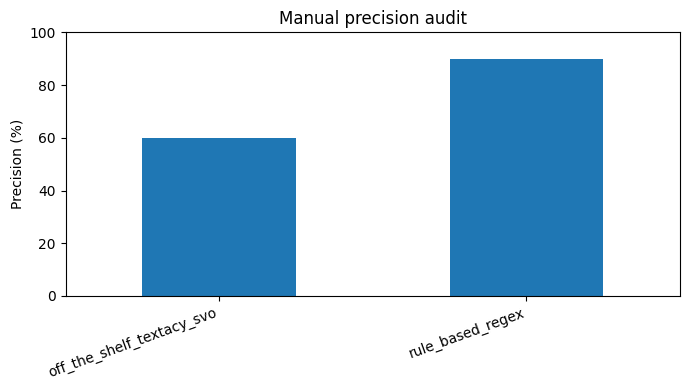

In [34]:
audited = pd.read_csv(OUTPUT_DIR / "manual_audit_done.csv")

audited["is_correct"] = audited["is_correct"].astype(int)
precision_table = (
	audited.groupby("strategy", as_index=False)
	.agg(
		audited_triples=("is_correct", "size"),
		correct_triples=("is_correct", "sum"),
		precision=("is_correct", "mean"),
	)
)
precision_table["precision_pct"] = (precision_table["precision"] * 100).round(2)
display(precision_table)

ax = precision_table.plot(kind="bar", x="strategy", y="precision_pct", legend=False, figsize=(7, 4), title="Manual precision audit")
ax.set_xlabel("")
ax.set_ylabel("Precision (%)")
ax.set_ylim(0, 100)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## 11. Results

### Coverage comparison

Both extraction strategies were applied to the same sample of movie plot summaries.

| Strategy | Raw Extractions | Unique Triples | Unique Entities | Relation Types |
|---|---:|---:|---:|---:|
| Rule-based regex | 35 | 35 | 64 | 9 |
| Off-the-shelf textacy SVO | 2449 | 2439 | 2589 | 1091 |

The off-the-shelf textacy SVO method produced far more triples, entities, and relation types than the rule-based method. This indicates much broader coverage, but not necessarily better quality. So, rule-based approach is explicitly limited to the its defined structure.

### Graph structure analysis

The structure of the resulting knowledge graphs differs significantly between the two methods.

| Strategy | Nodes | Edges | Weak Components | Largest Component | Density |
|---|---:|---:|---:|---:|---:|
| Rule-based regex | 64 | 35 | 29 | 4 | 0.008681 |
| Off-the-shelf textacy SVO | 2589 | 2439 | 482 | 1414 | 0.000338 |

### Interpretation of graph structure

The rule-based graph is small and highly fragmented:
- it contains many disconnected components (29)
- the largest connected component contains only 4 nodes
- density is relatively higher because the graph is very small

The off-the-shelf graph is much larger:
- it contains thousands of nodes and edges
- the largest component includes 1414 nodes, indicating a large connected structure
- however, the graph density is extremely low, showing that it is very sparse

This reflects the nature of the extraction methods:
- rule-based extraction creates small, isolated but precise facts
- off-the-shelf extraction connects many entities but introduces noise and weak links

Overall, the off-the-shelf graph is more suitable for exploratory analysis, while the rule-based graph is more interpretable and reliable.

### Manual precision audit

A manual audit of 10 sampled triples per method was conducted.

| Strategy | Audited Triples | Correct Triples | Precision |
|---|---:|---:|---:|
| Rule-based regex | 10 | 9 | 90% |
| Off-the-shelf textacy SVO | 10 | 6 | 60% |

### Interpretation

The results show a clear precision–coverage trade-off.

The rule-based regex method is conservative: it extracts only 35 unique triples, but achieves high manual precision of 90%. This means the rules are restrictive but reliable.

The off-the-shelf textacy SVO method extracts much more information: 2439 unique triples and 1091 relation types. However, its manual precision is lower at 60%, showing that broader extraction introduces more noise.

The very large number of relation types in the textacy output also suggests that relations are weakly normalized. Many extracted predicates are raw verb phrases rather than clean semantic relation labels.


### Error analysis

Typical off-the-shelf errors include:
- generic or uninformative subjects, such as `information` or `both`
- incorrect object boundaries, such as `to shoot him`
- shallow syntactic relations that are grammatically valid but semantically weak

Example incorrect triples:
- (`information`, `enables`, `Dorval accomplice`)
- (`both`, `wear`, `hat`)
- (`Doc`, `manages`, `to shoot him`)

### Limitations

- The manual audit sample is small, so precision estimates are approximate.
- Rule-based extraction has low recall because it only captures predefined relation patterns.
- Off-the-shelf SVO extraction has high coverage but produces noisy and weakly normalized relations.
- No coreference resolution is used, so pronouns and repeated references are not fully handled.
- The movie plot domain naturally creates sparse graphs because many characters and events appear only in one story.
- Support statistics are not very informative here because most triples occur only once.

### Conclusion

Rule-based extraction produced fewer but more reliable triples, while off-the-shelf textacy SVO extraction produced much broader but noisier output.

For this movie-plot knowledge graph task, the rule-based approach is better when precision and interpretability are important. The off-the-shelf approach is better for exploratory extraction, but it requires stronger post-processing, relation normalization, and filtering before the resulting graph can be considered high quality.